In [1]:
import pickle
import numpy as np
from matplotlib.ticker import ScalarFormatter
import matplotlib.transforms as mtransforms
import matplotlib.gridspec as gridspec
import matplotlib.pylab as pl

 
0.0009242 x + 17.9
 
1.221 x + 162.8


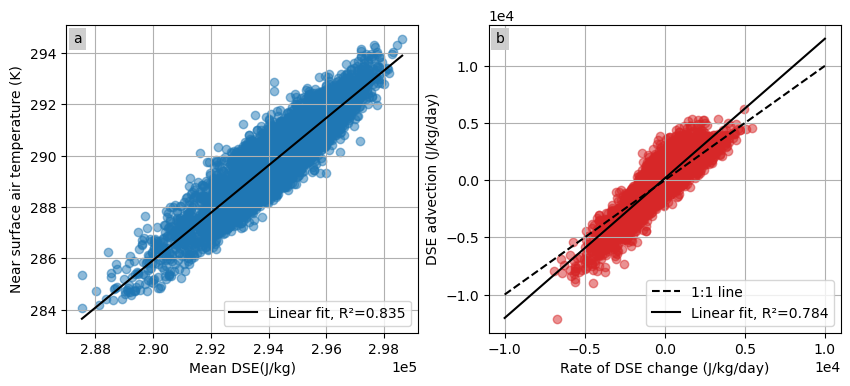

In [15]:
#plotting the graphs from the mean dse instead of summed dse

output_dir='/home/data/lab_project2/Steve/model_runs/aqua_planet/long-run/'

latc=45
output_file = output_dir+'dse_mean_'+str(latc)
with open(output_file, 'rb') as f:
    dse_master= pickle.load(f)
    
output_file = output_dir+'thresh95'
with open(output_file, 'rb') as f:
    thresh = pickle.load(f)
thresh_val= thresh[latc]  

dse_values = {'dse_diff':[], 'dse_tend':[], 'dse_low':[], 'T':[]}
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    T = dse_master['T'][i]
    dse=dse_master['dse_tend_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    dse_tend=((dse[1:]+dse[:-1])/2)
    
    dse_values['dse_diff'].append(dse_diff)
    dse_values['dse_tend'].append(dse_tend)
    dse_values['dse_low'].append(dse_low)
    dse_values['T'].append(T)


temp = np.concatenate(dse_values['T']) + thresh_val
dse = np.concatenate(dse_values['dse_low'])
dse_diff=np.concatenate(dse_values['dse_diff'])
dse_tend=np.concatenate(dse_values['dse_tend'])

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(1, 2)
fig=pl.figure(figsize=(10,4))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 

####################### dse vs temp #######################################

ax1.scatter(dse, temp, alpha=0.5)
ax1.grid(True)
x=dse
y=temp
#Linear regression
coeffs = np.polyfit(x, y, 1)
fit_fn = np.poly1d(coeffs)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = fit_fn(x_fit)
print(fit_fn)

y_pred = fit_fn(x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)

ax1.plot(x_fit, y_fit, 'k', label=f'Linear fit, R²={r2:.3f}')
ax1.legend(loc='lower right')
set_label(fig, ax1, 'a')
ax1.set_xlabel('Mean DSE(J/kg)')
ax1.set_ylabel('Near surface air temperature (K)')
ax1.xaxis.set_major_formatter(formatter)

################### tendency vs advection #################################

ax2.scatter(dse_diff, dse_tend, c='#d72728',alpha=0.5)
ax2.grid(True)
val = 1e4
xy=np.array([-1,0,1])*val
ax2.plot(xy, xy,color='k', linestyle='--', label='1:1 line')  

x = dse_diff
y = dse_tend
#Linear regression
coeffs = np.polyfit(x, y, 1)
fit_fn = np.poly1d(coeffs)
x_fit = np.linspace(-val, val, 200)
y_fit = fit_fn(x_fit)
print(fit_fn)

y_pred = fit_fn(x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax2.plot(x_fit, y_fit, 'k', label=f'Linear fit, R²={r2:.3f}')
ax2.set_xlabel('Rate of DSE change (J/kg/day)')
ax2.set_ylabel('DSE advection (J/kg/day)')
ax2.legend(loc='lower right')
set_label(fig, ax2, 'b')
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

fig.savefig('2.pdf', bbox_inches='tight')
fig.savefig('2.jpg',dpi=600, bbox_inches='tight')

0.0008716240163053267
 
0.0008716 x + 33.26
 
1.217 x + 494.8


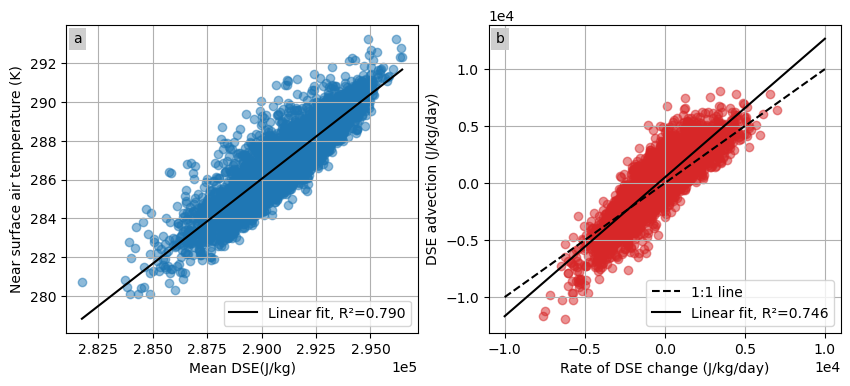

In [5]:
output_dir='/home/data/lab_project2/Steve/model_runs/aqua_planet/long-run/'

latc=50
output_file = output_dir+'dse_mean_'+str(latc)
with open(output_file, 'rb') as f:
    dse_master= pickle.load(f)
    
output_file = output_dir+'thresh95'
with open(output_file, 'rb') as f:
    thresh = pickle.load(f)
thresh_val= thresh[latc]  

dse_values = {'dse_diff':[], 'dse_tend':[], 'dse_low':[], 'T':[]}
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    T = dse_master['T'][i]
    dse=dse_master['dse_tend_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    dse_tend=((dse[1:]+dse[:-1])/2)
    
    dse_values['dse_diff'].append(dse_diff)
    dse_values['dse_tend'].append(dse_tend)
    dse_values['dse_low'].append(dse_low)
    dse_values['T'].append(T)


temp = np.concatenate(dse_values['T']) + thresh_val
dse = np.concatenate(dse_values['dse_low'])
dse_diff=np.concatenate(dse_values['dse_diff'])
dse_tend=np.concatenate(dse_values['dse_tend'])

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(1, 2)
fig=pl.figure(figsize=(10,4))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 

####################### dse vs temp #######################################

ax1.scatter(dse, temp, alpha=0.5)
ax1.grid(True)
x=dse
y=temp
#Linear regression
coeffs = np.polyfit(x, y, 1)
fit_fn = np.poly1d(coeffs)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = fit_fn(x_fit)
print(fit_fn[1])
print(fit_fn)

y_pred = fit_fn(x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)

ax1.plot(x_fit, y_fit, 'k', label=f'Linear fit, R²={r2:.3f}')
ax1.legend(loc='lower right')
set_label(fig, ax1, 'a')
ax1.set_xlabel('Mean DSE(J/kg)')
ax1.set_ylabel('Near surface air temperature (K)')
ax1.xaxis.set_major_formatter(formatter)

################### tendency vs advection #################################

ax2.scatter(dse_diff, dse_tend, c='#d72728',alpha=0.5)
ax2.grid(True)
val = 1e4
xy=np.array([-1,0,1])*val
ax2.plot(xy, xy,color='k', linestyle='--', label='1:1 line')  

x = dse_diff
y = dse_tend
#Linear regression
coeffs = np.polyfit(x, y, 1)
fit_fn = np.poly1d(coeffs)
x_fit = np.linspace(-val, val, 200)
y_fit = fit_fn(x_fit)
print(fit_fn)

y_pred = fit_fn(x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax2.plot(x_fit, y_fit, 'k', label=f'Linear fit, R²={r2:.3f}')
ax2.set_xlabel('Rate of DSE change (J/kg/day)')
ax2.set_ylabel('DSE advection (J/kg/day)')
ax2.legend(loc='lower right')
set_label(fig, ax2, 'b')
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

#fig.savefig('2.pdf', bbox_inches='tight')
#fig.savefig('2.jpg',dpi=600, bbox_inches='tight')

0.0009476501077694566
 
0.0009477 x + 11.24
 
1.257 x - 30.86


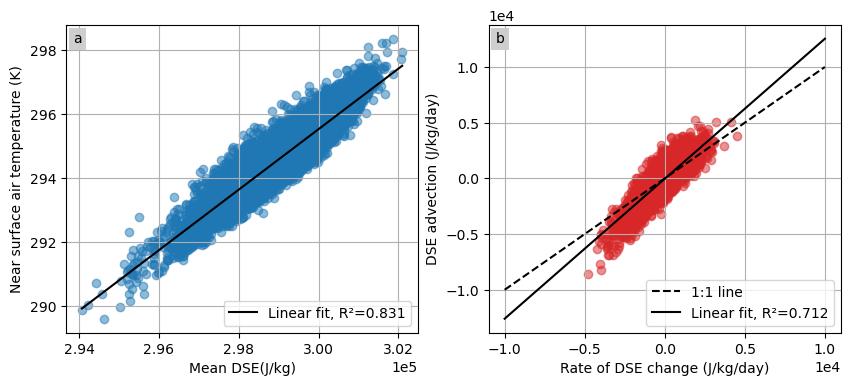

In [6]:
output_dir='/home/data/lab_project2/Steve/model_runs/aqua_planet/long-run/'

latc=35
output_file = output_dir+'dse_mean_'+str(latc)
with open(output_file, 'rb') as f:
    dse_master= pickle.load(f)
    
output_file = output_dir+'thresh95'
with open(output_file, 'rb') as f:
    thresh = pickle.load(f)
thresh_val= thresh[latc]  

dse_values = {'dse_diff':[], 'dse_tend':[], 'dse_low':[], 'T':[]}
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    T = dse_master['T'][i]
    dse=dse_master['dse_tend_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    dse_tend=((dse[1:]+dse[:-1])/2)
    
    dse_values['dse_diff'].append(dse_diff)
    dse_values['dse_tend'].append(dse_tend)
    dse_values['dse_low'].append(dse_low)
    dse_values['T'].append(T)


temp = np.concatenate(dse_values['T']) + thresh_val
dse = np.concatenate(dse_values['dse_low'])
dse_diff=np.concatenate(dse_values['dse_diff'])
dse_tend=np.concatenate(dse_values['dse_tend'])

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(1, 2)
fig=pl.figure(figsize=(10,4))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 

####################### dse vs temp #######################################

ax1.scatter(dse, temp, alpha=0.5)
ax1.grid(True)
x=dse
y=temp
#Linear regression
coeffs = np.polyfit(x, y, 1)
fit_fn = np.poly1d(coeffs)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = fit_fn(x_fit)
print(fit_fn[1])
print(fit_fn)

y_pred = fit_fn(x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)

ax1.plot(x_fit, y_fit, 'k', label=f'Linear fit, R²={r2:.3f}')
ax1.legend(loc='lower right')
set_label(fig, ax1, 'a')
ax1.set_xlabel('Mean DSE(J/kg)')
ax1.set_ylabel('Near surface air temperature (K)')
ax1.xaxis.set_major_formatter(formatter)

################### tendency vs advection #################################

ax2.scatter(dse_diff, dse_tend, c='#d72728',alpha=0.5)
ax2.grid(True)
val = 1e4
xy=np.array([-1,0,1])*val
ax2.plot(xy, xy,color='k', linestyle='--', label='1:1 line')  

x = dse_diff
y = dse_tend
#Linear regression
coeffs = np.polyfit(x, y, 1)
fit_fn = np.poly1d(coeffs)
x_fit = np.linspace(-val, val, 200)
y_fit = fit_fn(x_fit)
print(fit_fn)

y_pred = fit_fn(x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax2.plot(x_fit, y_fit, 'k', label=f'Linear fit, R²={r2:.3f}')
ax2.set_xlabel('Rate of DSE change (J/kg/day)')
ax2.set_ylabel('DSE advection (J/kg/day)')
ax2.legend(loc='lower right')
set_label(fig, ax2, 'b')
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

#fig.savefig('2.pdf', bbox_inches='tight')
#fig.savefig('2.jpg',dpi=600, bbox_inches='tight')